<a href="https://colab.research.google.com/github/Jamila-Hanif/CAA-Heathrow-Punctuality-KPIs/blob/main/airport_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (10,6)


In [ ]:
# 1.  RAW Heathrow flight data - each row = 1 flight
df = pd.read_excel('/content/2024 On Time Performance Tables.xlsx', header=1)

# the column names from the first row of the DataFrame
df.columns = df.iloc[0]

# Drop the first row as it's now duplicated in the column names
df = df[1:].reset_index(drop=True)

# Clean column names: remove newlines, extra spaces, and replace spaces with underscores
df.columns = df.columns.astype(str).str.strip().str.replace('\n', ' ').str.replace(' ', '_').str.replace('__', '_')

# Drop any column that was originally unnamed and now has a 'nan' as a name
df = df.loc[:, df.columns != 'nan']

print("=== DATA CHECK ===")
print(f"Total flights loaded: {len(df):,}")
print(f"Columns in file: {df.columns.tolist()}")
print("\nFirst 3 rows:")
display(df.head(3))

=== DATA CHECK ===
Total flights loaded: 26
Columns in file: ['Reporting_Period', 'Reporting_Airport', 'Flights_on_time_(<15mins)_Percent', 'Flights_on_time_(<15mins)_Percent_Previous_Year', 'Average_Delay_Minutes', 'Average_Delay_Minutes_Previous_Year', 'Flights_Cancelled_Percent', 'Flights_Cancelled_Percent_Previous_Year', 'Total_Flights', 'Total_Flights_Previous_Year']

First 3 rows:


,Reporting_Period,Reporting_Airport,Flights_on_time_(<15mins)_Percent,Flights_on_time_(<15mins)_Percent_Previous_Year,Average_Delay_Minutes,Average_Delay_Minutes_Previous_Year,Flights_Cancelled_Percent,Flights_Cancelled_Percent_Previous_Year,Total_Flights,Total_Flights_Previous_Year
0,2024,ABERDEEN,75.011194,68.68983,13.020868,18.222656,4.412221,4.390553,29033,30019
1,2024,BELFAST CITY (GEORGE BEST),78.037937,75.140435,11.75653,12.654024,3.303036,3.595138,30366,29373
2,2024,BELFAST INTERNATIONAL,75.146199,68.213468,14.856324,19.118587,0.449039,1.060467,47880,43660


In [ ]:
# Filter for Heathrow only
heathrow = df[df['Reporting_Airport'].str.contains('HEATHROW', case=False, na=False)]

if len(heathrow) == 0:
    print("Heathrow not found. Check airport name spelling in your file")
else:
    print("\n=== HEATHROW 2024 KPI ===")
    on_time_pct = heathrow['Flights_on_time_(<15mins)_Percent'].iloc[0]
    delayed_pct = 100 - on_time_pct

    print(f"Flights on-time <15min: {on_time_pct:.2f}%")
    print(f"Flights delayed 15min+: {delayed_pct:.2f}%")

    # Calculate delayed flights if CAA file has total flights column
    if 'Flights' in df.columns:
        total_flights = heathrow['Flights'].iloc[0]
        delayed_flights = total_flights * (delayed_pct/100)
        print(f"Total flights: {total_flights:,.0f}")
        print(f"Delayed flights: {delayed_flights:,.0f}")


=== HEATHROW 2024 KPI ===
Flights on-time <15min: 67.33%
Flights delayed 15min+: 32.67%


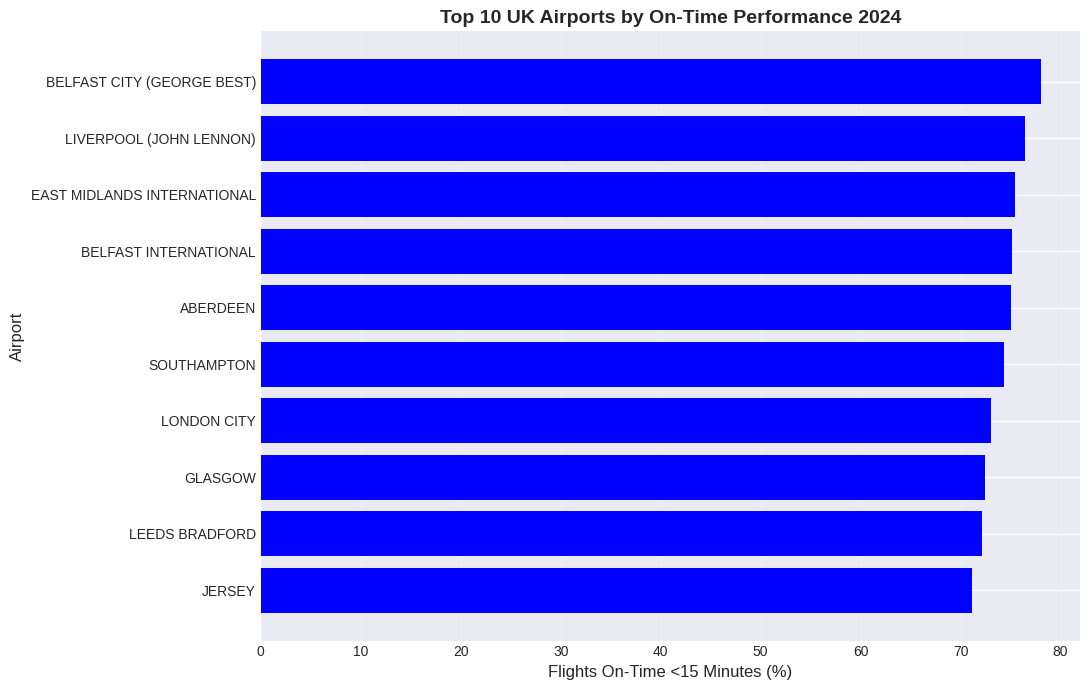

In [ ]:
# Sort all airports by on-time %(benchmark KPIs)
df['Flights_on_time_(<15mins)_Percent'] = pd.to_numeric(df['Flights_on_time_(<15mins)_Percent'], errors='coerce')
top10_airports = df.nlargest(10, 'Flights_on_time_(<15mins)_Percent')

plt.figure(figsize=(11,7))
bars = plt.barh(top10_airports['Reporting_Airport'], top10_airports['Flights_on_time_(<15mins)_Percent'], color='blue')
plt.title('Top 10 UK Airports by On-Time Performance 2024', fontsize=14, weight='bold')
plt.xlabel('Flights On-Time <15 Minutes (%)', fontsize=12)
plt.ylabel('Airport', fontsize=12)
plt.gca().invert_yaxis()

# Highlight Heathrow in red if it’s there
for i, airport in enumerate(top10_airports['Reporting_Airport']):
    if 'HEATHROW' in airport.upper():
        bars[i].set_color('blue')

plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('uk_airports_ontime_chart.png', dpi=300)
plt.show()

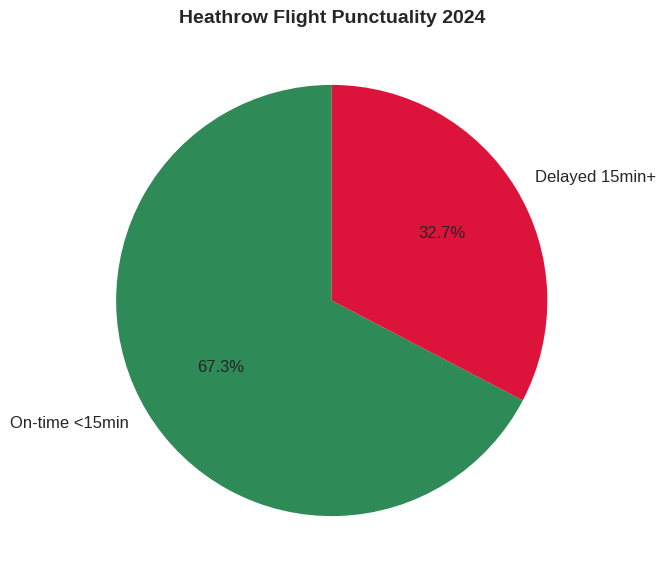

In [ ]:
if len(heathrow) > 0:
    labels = ['On-time <15min', 'Delayed 15min+']
    sizes = [on_time_pct, delayed_pct]
    colors = ['#2E8B57', '#DC143C']

    plt.figure(figsize=(7,7))
    plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90, textprops={'fontsize':12})
    plt.title('Heathrow Flight Punctuality 2024', fontsize=14, weight='bold')
    plt.savefig('heathrow_punctuality_pie.png', dpi=300)
    plt.show()